In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.io
import torch
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from emle.models import EMLE
from emle.train._utils import pad_to_max
import pickle as pkl

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5002

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
data = pkl.load(
    open(
        "/scratch1/joao/tip3p_final/bespoke_models/sampling_iter3/merged_ref_data.pkl",
        "rb",
    )
)

# Get padded tensors
z = pad_to_max(data["z"]).to(device=device, dtype=torch.long)
xyz_qm = pad_to_max(data["xyz_qm"]).to(device=device, dtype=dtype)
xyz_mm = pad_to_max(data["xyz_mm"]).to(device=device, dtype=dtype)
charges_mm = pad_to_max(data["charges_mm"]).to(device=device, dtype=dtype)

### Assign TIP3P LJ Parameters

In [4]:
# TIP3P LJ Parameters
# O_sigma = 3.1507 Å, O_epsilon = 0.1521 kcal/mol
# H_sigma = 1.0 Å, H_epsilon = 0.0 kcal/mol
O_sigma = 3.1507 * ANGSTROM_TO_BOHR
O_epsilon = 0.1521 * 4.184 / HARTREE_TO_KJ_MOL
H_sigma = 1.0 * ANGSTROM_TO_BOHR
H_epsilon = 0.0

sigma_mm = charges_mm.clone()
sigma_mm[charges_mm == -0.834] = O_sigma
sigma_mm[charges_mm == 0.417] = H_sigma

epsilon_mm = charges_mm.clone()
epsilon_mm[charges_mm == -0.834] = O_epsilon
epsilon_mm[charges_mm == 0.417] = H_epsilon

# Now pad adding 0s for the QM atoms
num_qm_atoms = z.shape[1]
sigma_mm = torch.cat(
    [
        torch.zeros((sigma_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        sigma_mm,
    ],
    dim=1,
)
epsilon_mm = torch.cat(
    [
        torch.zeros((epsilon_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        epsilon_mm,
    ],
    dim=1,
)

# Get idx_mm
atom_indices = (
    torch.arange(charges_mm.shape[1])
    .unsqueeze(0)
    .expand(*charges_mm.shape)
    .to(device=device, dtype=torch.long)
)
idx_mm = torch.where(charges_mm != 0.0, atom_indices + num_qm_atoms, 0)

# Recreate nagl_params dictionary
nagl_params = {
    "lj_sigma_mm": sigma_mm,
    "lj_eps_mm": epsilon_mm,
}

### Create EMLE model

In [5]:
model = scipy.io.loadmat("../xdm_moments_rcrit/ligand_patched_reference_iter2_c6.mat")
model["sigma_scale_ref"] = np.ones_like(model["c6_ref"])
ones_file = "ligand_patched_reference_iter2_c6_sigma_scales_ones.mat"
scipy.io.savemat(ones_file, model)

In [6]:
emle = EMLE(
    model=ones_file,
    device=device,
    dtype=dtype,
    alpha_mode="reference",
    dispersion_mode="lj",
    nagl_params=nagl_params,
)
emle_base = emle._emle_base

### Fine-tune the Fedorov relation via Zwanzig reweighting

In [7]:
def dG(energies, beta):
    """Compute solvation free energy using Zwanzig equation."""
    return -(1 / beta) * torch.logsumexp(-beta * energies, dim=1) + (
        1 / beta
    ) * torch.log(torch.tensor(energies.shape[1], dtype=torch.float32))

In [ ]:
# Define constants
T = 298.15
kB = 3.166811563e-6  # Hartree/K
kbT = kB * T
beta = 1.0 / kbT
NMOL = 20

In [9]:
# Calculate dG-LJ
with torch.no_grad():
    e_static, e_ind, _, _, e_lj = emle.forward(
        z, charges_mm, xyz_qm, xyz_mm, idx_mm=idx_mm
    )

dG_lj_init = dG(e_lj.view(NMOL, -1), beta)

mols = [
    "1_4-dioxane",
    "1-propanethiol",
    "2-pentanone",
    "aceticacid",
    "acetonitrile",
    "aniline",
    "benzamide",
    "benzene",
    "ethylphenylether",
    "methanol",
    "methylbenzoate",
    "methylpentanoate",
    "m-hydroxybenzaldehyde",
    "naphthalene",
    "n-octane",
    "n-pentane",
    "o-cresol",
    "pyridine",
    "thioanisole",
    "water",
]

sign_err = [
    0.75,  # 1_4-dioxane
    1.46,  # 1-propanethiol
    0.03,  # 2-pentanone
    0.99,  # aceticacid
    -1.55,  # acetonitrile
    0.00,  # aniline
    0.42,  # benzamide
    -0.88,  # benzene
    -0.30,  # ethylphenylether
    1.10,  # methanol
    -1.49,  # methylbenzoate
    -0.53,  # methylpentanoate
    0.90,  # m-hydroxybenzaldehyde
    -0.91,  # naphthalene
    0.35,  # n-octane
    0.48,  # n-pentane
    1.59,  # o-cresol
    -0.09,  # pyridine
    0.60,  # thioanisole
    0.00,  # water
]

# Signed errors
sign_err = torch.tensor(sign_err) * 4.184 / HARTREE_TO_KJ_MOL
# DeltaG_calc - (DeltaG_calc - DeltaG_exp) = DeltaG_exp
dG_lj_ref = dG_lj_init - sign_err.to(device=device, dtype=dtype)

In [10]:
# Optimize
sigma_scale = emle._emle_base.ref_values_sigma_scale
optimizer = torch.optim.Adam([sigma_scale], lr=1e-3)
n_epochs = 250
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Get the LJ deltaG with the updated parameters
    *_, e_lj = emle.forward(z, charges_mm, xyz_qm, xyz_mm, idx_mm=idx_mm)
    e_lj = e_lj.view(NMOL, -1)
    dG_lj = dG(e_lj, beta)

    # Update sigma scale for gpr
    emle_base._ref_mean_sigma_scale, emle_base._c_sigma_scale = emle_base._get_c(
        emle_base._n_ref,
        emle_base.ref_values_sigma_scale,
        emle_base._Kinv,
    )

    # Regularize sigma scale to be close to 1.0
    mask = (
        torch.arange(
            emle_base.ref_values_sigma_scale.shape[1],
            device=emle_base._n_ref.device,
        )
        < emle_base._n_ref[:, None]
    )
    reg_loss = (
        1e-2
        * torch.sum((emle_base.ref_values_sigma_scale - 1) ** 2 * mask)
        / torch.sum(emle_base._n_ref)
    )

    # Compute loss
    loss = torch.mean((dG_lj_ref - dG_lj) ** 2) / torch.std(dG_lj_ref)
    loss += reg_loss
    loss.backward(retain_graph=True)
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item():.6f}")

# Save EMLE model with updated parameters
model_mat = scipy.io.loadmat(ones_file)
model_mat["sigma_scale_ref"] = emle_base.ref_values_sigma_scale.detach().cpu().numpy()
scipy.io.savemat("ligand_patched_reference_iter2_c6_updated_sigma_scale.mat", model_mat)

Epoch 10/250, Loss: 0.000196
Epoch 20/250, Loss: 0.000142
Epoch 30/250, Loss: 0.000103
Epoch 40/250, Loss: 0.000078
Epoch 50/250, Loss: 0.000061
Epoch 60/250, Loss: 0.000050
Epoch 70/250, Loss: 0.000042
Epoch 80/250, Loss: 0.000037
Epoch 90/250, Loss: 0.000034
Epoch 100/250, Loss: 0.000031
Epoch 110/250, Loss: 0.000030
Epoch 120/250, Loss: 0.000029
Epoch 130/250, Loss: 0.000028
Epoch 140/250, Loss: 0.000027
Epoch 150/250, Loss: 0.000026
Epoch 160/250, Loss: 0.000026
Epoch 170/250, Loss: 0.000026
Epoch 180/250, Loss: 0.000025
Epoch 190/250, Loss: 0.000025
Epoch 200/250, Loss: 0.000025
Epoch 210/250, Loss: 0.000025
Epoch 220/250, Loss: 0.000024
Epoch 230/250, Loss: 0.000024
Epoch 240/250, Loss: 0.000024
Epoch 250/250, Loss: 0.000024


# Plots

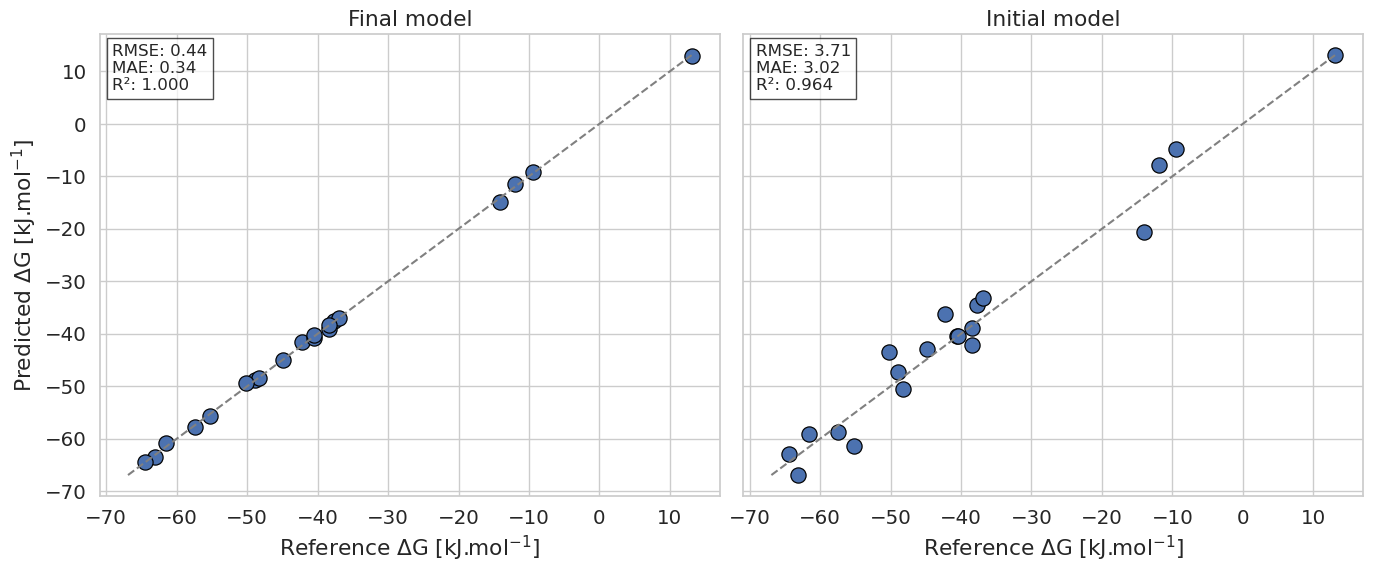

In [11]:
sns.set(style="whitegrid", font_scale=1.3)

dG_lj_calc = dG_lj.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_lj_init = dG_lj_init.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_ref = dG_lj_ref.detach().cpu().numpy() * HARTREE_TO_KJ_MOL

stats_calc = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_calc)),
    mean_absolute_error(dG_ref, dG_lj_calc),
    r2_score(dG_ref, dG_lj_calc),
)
stats_init = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_init)),
    mean_absolute_error(dG_ref, dG_lj_init),
    r2_score(dG_ref, dG_lj_init),
)

min_v = min(dG_ref.min(), dG_lj_calc.min(), dG_lj_init.min())
max_v = max(dG_ref.max(), dG_lj_calc.max(), dG_lj_init.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Final model
ax = axes[0]
sns.scatterplot(x=dG_ref, y=dG_lj_calc, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Final model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("Predicted ΔG [kJ.mol$^{-1}$]")

rmse, mae, r2 = stats_calc
ax.text(
    0.02,
    0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

# Initial model
ax = axes[1]
sns.scatterplot(x=dG_ref, y=dG_lj_init, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Initial model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("")

rmse, mae, r2 = stats_init
ax.text(
    0.02,
    0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

plt.tight_layout()
plt.show()

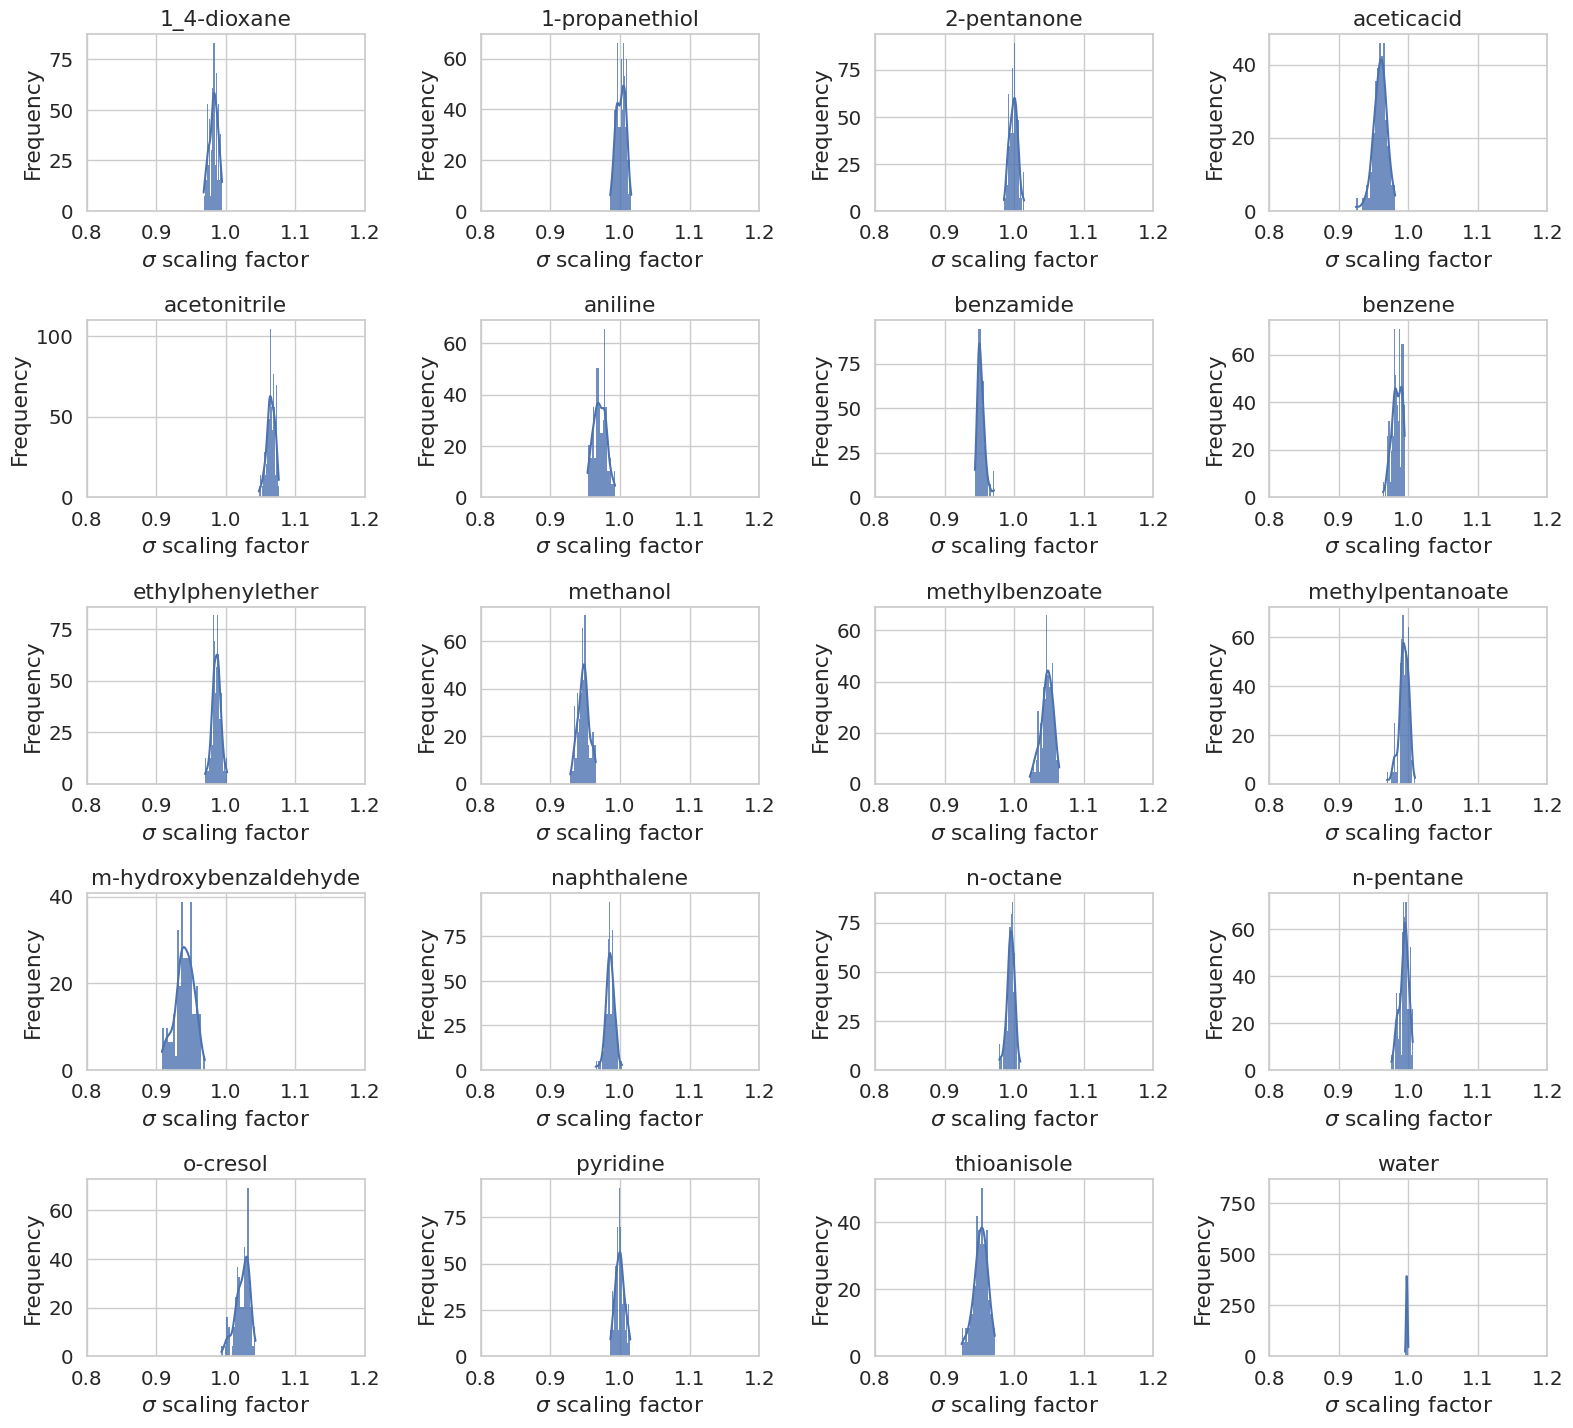

In [12]:
*_, sigma_scale = emle_base(
    z, xyz_qm, torch.zeros(z.shape[0], device=device, dtype=dtype)
)


chunk_size = int(sigma_scale.shape[0] / len(mols))
num_mols = len(mols)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, mol in enumerate(mols):
    ax = axes[i]
    data_block = sigma_scale[i * chunk_size : (i + 1) * chunk_size, 0]
    sns.histplot(
        data_block.detach().cpu(),
        bins=20,
        alpha=0.8,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
    )
    ax.set_title(mol)
    ax.set_xlabel(r"$\sigma$ scaling factor")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0.8, 1.2)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

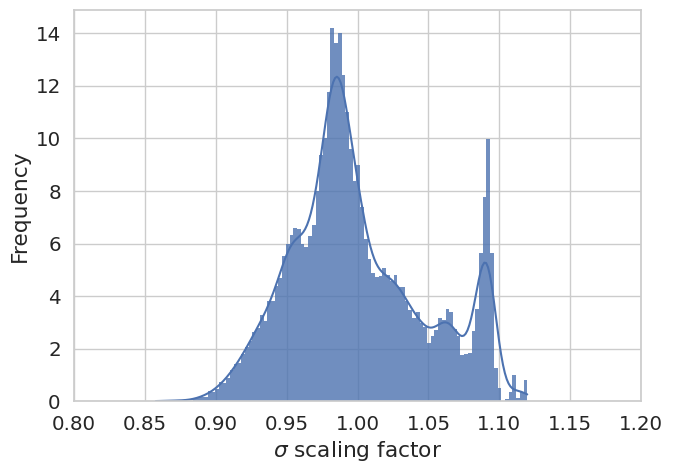

In [13]:
all_sigma = sigma_scale.flatten()
all_sigma = all_sigma[all_sigma > 0.0]

plt.figure(figsize=(7, 5))
sns.histplot(
    all_sigma.detach().cpu(),
    bins=100,
    alpha=0.8,
    stat="density",
    edgecolor=None,
    linewidth=0,
    kde=True,
)
plt.xlabel(r"$\sigma$ scaling factor")
plt.ylabel("Frequency")
plt.xlim(0.8, 1.2)
plt.tight_layout()
plt.show()